<a href="https://www.kaggle.com/code/lalit7881/nvidia-reasoning-challenge?scriptVersionId=306338233" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/train.csv
/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/test.csv


## Improved Color Palette

In [2]:
COLORS = {
    'bit_manipulation': '#185FA5',
    'physics_gravity':  '#0F6E56',
    'unit_conversion':  '#3B6D11',
    'text_cipher':      '#534AB7',
    'numeral_system':   '#3C3489',
    'symbol_transform': '#993C1D',
}
LABELS = {
    'bit_manipulation': 'Bit manipulation',
    'physics_gravity':  'Physics / gravity',
    'unit_conversion':  'Unit conversion',
    'text_cipher':      'Text cipher',
    'numeral_system':   'Numeral system',
    'symbol_transform': 'Symbol transform',
}


## Simple Step-by-Step Workflow

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [4]:
train = pd.read_csv('/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/test.csv')

print(f'Train Shape: {train.shape}')
print(f'Test Shape: {test.shape}')

Train Shape: (9500, 3)
Test Shape: (3, 2)


## Preview Data

In [5]:
train.head(3)

,id,prompt,answer
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book


In [6]:
train.head(3)

,id,prompt,answer
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9500 entries, 0 to 9499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      9500 non-null   object
 1   prompt  9500 non-null   object
 2   answer  9500 non-null   object
dtypes: object(3)
memory usage: 222.8+ KB


In [8]:
train.columns

Index(['id', 'prompt', 'answer'], dtype='object')

In [9]:
train.isnull().sum()

id        0
prompt    0
answer    0
dtype: int64

In [10]:
train.duplicated().sum()

np.int64(0)

##  Puzzle Type Classification¶

## Simple Function

In [11]:
def classify_puzzle(prompt):
    p = prompt.lower()

    if 'bit' in p or 'binary' in p:
        return 'bit_manipulation'
    
    if 'numeral' in p:
        return 'numeral_system'
    
    if 'encrypt' in p or 'cipher' in p:
        return 'text_cipher'
    
    if 'equation' in p or 'solve' in p:
        return 'symbol_transform'
    
    if 'unit' in p:
        return 'unit_conversion'
    
    if 'gravity' in p:
        return 'physics_gravity'
    
    return 'other'

## Apply on Data

In [12]:
train['type'] = train['prompt'].apply(classify_puzzle)
test['type']  = test['prompt'].apply(classify_puzzle)

## Simple Features

In [13]:
train['prompt_len'] = train['prompt'].str.len()
train['answer_len'] = train['answer'].str.len()

# count examples like: input -> output
train['n_examples'] = train['prompt'].str.count('->')

# check numeric answer
train['is_numeric_ans'] = train['answer'].str.isnumeric()

## View Results

In [14]:
print("Type Distribution:\n")
print(train['type'].value_counts())

print("\nTotal rows:", len(train))

Type Distribution:

type
bit_manipulation    1988
other               1597
unit_conversion     1594
numeral_system      1576
symbol_transform    1555
text_cipher         1190
Name: count, dtype: int64

Total rows: 9500


## Dashboard - Overview

## Create Figure Layout

In [15]:
from matplotlib.gridspec import GridSpec

Text(0, 0, '9,500\npuzzles')

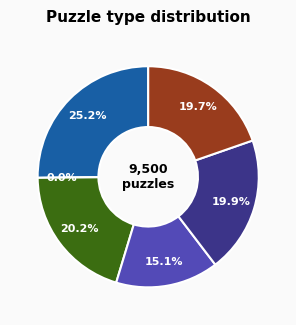

In [16]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#FAFAFA')
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

types_ordered = list(COLORS.keys())
counts = [len(train[train['type']==t]) for t in types_ordered]
clrs   = [COLORS[t] for t in types_ordered]
lbls   = [LABELS[t] for t in types_ordered]

# 1. Donut chart 
ax1 = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax1.pie(
    counts, colors=clrs, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(8); at.set_color('white'); at.set_fontweight('bold')
ax1.set_title('Puzzle type distribution', fontsize=11, fontweight='bold', pad=12)
ax1.text(0, 0, f'{len(train):,}\npuzzles', ha='center', va='center', fontsize=9, fontweight='bold')

In [17]:
ax2 = fig.add_subplot(gs[0, 1:])
bars = ax2.barh(lbls[::-1], counts[::-1], color=clrs[::-1], height=0.6, edgecolor='white')
for bar, cnt in zip(bars, counts[::-1]):
    ax2.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{cnt:,}', va='center', fontsize=9)
ax2.set_xlabel('Number of puzzles', fontsize=9)
ax2.set_title('Puzzle counts — perfectly balanced dataset', fontsize=11, fontweight='bold')
ax2.spines[['top','right']].set_visible(False)
ax2.set_xlim(0, 1850)

(0.0, 1850.0)

In [18]:
ax3 = fig.add_subplot(gs[1, :2])
for i, t in enumerate(types_ordered):
    sub = train[train['type']==t]['prompt_len']
    ax3.boxplot(sub, positions=[i], widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor=COLORS[t], alpha=0.7),
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax3.set_xticks(range(len(types_ordered)))
ax3.set_xticklabels([LABELS[t] for t in types_ordered], rotation=20, ha='right', fontsize=8)
ax3.set_ylabel('Prompt length (chars)', fontsize=9)
ax3.set_title('Prompt length by puzzle type (bit manipulation is longest — most complex)', fontsize=11, fontweight='bold')
ax3.spines[['top','right']].set_visible(False)


In [19]:
ax4 = fig.add_subplot(gs[1, 2])
mean_ans_len = [train[train['type']==t]['answer_len'].mean() for t in types_ordered]
ax4.barh(lbls[::-1], [mean_ans_len[types_ordered.index(t)] for t in types_ordered[::-1]],
         color=clrs[::-1], height=0.6)
ax4.set_xlabel('Mean answer length (chars)', fontsize=9)
ax4.set_title('Avg answer\nlength', fontsize=11, fontweight='bold')
ax4.spines[['top','right']].set_visible(False)


In [20]:
ax5 = fig.add_subplot(gs[2, :2])
for i, t in enumerate(types_ordered):
    sub = train[train['type']==t]['n_examples']
    ax5.scatter([i]*len(sub), sub,
                color=COLORS[t], alpha=0.04, s=8)
    ax5.plot([i-0.3, i+0.3], [sub.mean(), sub.mean()],
             color=COLORS[t], linewidth=3)
ax5.set_xticks(range(len(types_ordered)))
ax5.set_xticklabels([LABELS[t] for t in types_ordered], rotation=20, ha='right', fontsize=8)
ax5.set_ylabel('Number of examples (→ arrows)', fontsize=9)
ax5.set_title('In-context examples per puzzle (bit manipulation has most — hardest to crack)', fontsize=11, fontweight='bold')
ax5.spines[['top','right']].set_visible(False)

In [21]:
ax6 = fig.add_subplot(gs[2, 2])
numeric_n = train['is_numeric_ans'].sum()
text_n = (~train['is_numeric_ans']).sum()
ax6.pie([numeric_n, text_n], labels=['Numeric\n(float/int)', 'Text\n(string)'],
        colors=['#185FA5', '#534AB7'], autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax6.set_title('Answer\nformat split', fontsize=11, fontweight='bold')

plt.suptitle('NVIDIA Nemotron Reasoning Challenge — EDA Dashboard', 
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Dashboard saved.')

<Figure size 640x480 with 0 Axes>

Dashboard saved.


In [22]:
for t in types_ordered:
    subset = train[train['type'] == t]
    
    if subset.empty:
        continue   # skip missing types safely
    
    row = subset.iloc[0]
    
    print("="*70)
    print(f"TYPE: {LABELS[t].upper()}")
    print("="*70)
    print(row)

TYPE: BIT MANIPULATION
id                                                         00066667
prompt            In Alice's Wonderland, a secret bit manipulati...
answer                                                     10010111
type                                               bit_manipulation
prompt_len                                                      468
answer_len                                                        8
n_examples                                                        9
is_numeric_ans                                                 True
Name: 0, dtype: object
TYPE: UNIT CONVERSION
id                                                         00208201
prompt            In Alice's Wonderland, a secret unit conversio...
answer                                                        16.65
type                                                unit_conversion
prompt_len                                                      245
answer_len                                      

In [23]:
def solve_roman(prompt: str):
    m = re.search(r'number\s*(\d+)', prompt.lower())
    if not m:
        return None
    
    n = int(m.group(1))
    
    val = [1000,900,500,400,100,90,50,40,10,9,5,4,1]
    sym = ['M','CM','D','CD','C','XC','L','XL','X','IX','V','IV','I']
    
    result = []
    for v, s in zip(val, sym):
        count = n // v
        result.append(s * count)
        n -= v * count
    
    return ''.join(result)

In [24]:
def solve_physics(prompt: str):
    pairs = re.findall(r't\s*=\s*([\d.]+)\s*s.*?distance\s*=\s*([\d.]+)', prompt.lower())
    
    if not pairs:
        return None
    
    gs = []
    for t, d in pairs:
        t, d = float(t), float(d)
        if t > 0:
            gs.append(2 * d / (t ** 2))
    
    if not gs:
        return None
    
    g = np.mean(gs)
    
    # Extract query time after "Now"
    query_part = prompt.split('now')[-1].lower()
    m = re.search(r't\s*=\s*([\d.]+)', query_part)
    
    if not m:
        return None
    
    t = float(m.group(1))
    return round(0.5 * g * t**2, 2)

In [25]:
def solve_unit(prompt: str):
    pairs = re.findall(r'([\d.]+)\s*m\s*(?:becomes|=)\s*([\d.]+)', prompt.lower())
    
    if not pairs:
        return None
    
    ratios = []
    for i, o in pairs:
        i, o = float(i), float(o)
        if i != 0:
            ratios.append(o / i)
    
    if not ratios:
        return None
    
    ratio = np.mean(ratios)
    
    # Find query number
    m = re.search(r'(?:convert|measurement)[^0-9]*([\d.]+)', prompt.lower())
    
    if not m:
        m = re.search(r'([\d.]+)\s*m\s*$', prompt.strip().lower())
    
    if not m:
        return None
    
    return round(float(m.group(1)) * ratio, 2)

In [26]:
def solve_cipher(prompt: str):
    lines = [l.strip() for l in prompt.split('\n') if '->' in l]
    
    mapping = {}
    
    # Build mapping
    for line in lines:
        left, right = line.split('->')
        left_words = left.strip().split()
        right_words = right.strip().split()
        
        for lw, rw in zip(left_words, right_words):
            if len(lw) == len(rw):
                for c1, c2 in zip(lw, rw):
                    mapping[c1] = c2
    
    # Query
    m = re.search(r'decrypt.*?:\s*(.+)', prompt.lower())
    if not m:
        return None
    
    query = m.group(1).strip()
    
    decoded = []
    for ch in query:
        if ch == ' ':
            decoded.append(' ')
        elif ch in mapping:
            decoded.append(mapping[ch])
        else:
            decoded.append('?')
    
    result = ''.join(decoded)
    
    # Allow partial decoding (improved vs your version)
    if result.count('?') / max(1, len(result)) < 0.3:
        return result.replace('?', '')
    
    return None


In [27]:
def solve_prompt(prompt: str):
    prompt_lower = prompt.lower()
    
    if 'roman' in prompt_lower:
        return solve_roman(prompt)
    
    elif 'gravity' in prompt_lower or 'distance' in prompt_lower:
        return solve_physics(prompt)
    
    elif 'convert' in prompt_lower or 'measurement' in prompt_lower:
        return solve_unit(prompt)
    
    elif 'decrypt' in prompt_lower:
        return solve_cipher(prompt)
    
    return None


print("✅ All solvers ready (optimized & robust)")

✅ All solvers ready (optimized & robust)


##  Accuracy Benchmark

In [28]:
def is_correct(pred, truth):
    if pred is None:
        return False
    
    try:
        p = float(str(pred))
        t = float(str(truth))
        return abs(p - t) / max(abs(t), 1e-9) < 1e-3
    except:
        return str(pred).strip().upper() == str(truth).strip().upper()



In [29]:
SOLVERS = [
    ('Numeral system',  'numeral_system',  solve_roman),
    ('Physics gravity', 'physics_gravity', solve_physics),
    ('Unit conversion', 'unit_conversion', solve_unit),
    ('Text cipher',     'text_cipher',     solve_cipher),
]

results = {}


In [30]:
print(f"{'Solver':<22} {'Correct':>10} {'Total':>10} {'Accuracy':>10}")
print("-" * 60)
for name, type_key, fn in SOLVERS:
    
    subset = train[train['type'] == type_key]
    total = len(subset)
    
    if total == 0:
        print(f"{name:<22} {'0':>10} {'0':>10} {'0.0%':>10}")
        results[type_key] = (0, 0, 0.0)
        continue
    
    # Faster than iterrows
    preds = subset['prompt'].apply(fn)
    correct = sum(is_correct(p, t) for p, t in zip(preds, subset['answer']))
    
    acc = (correct / total) * 100
    results[type_key] = (correct, total, acc)
    
    print(f"{name:<22} {correct:>10,} {total:>10,} {acc:>9.2f}%")


Solver                    Correct      Total   Accuracy
------------------------------------------------------------
Numeral system              1,576      1,576    100.00%
Physics gravity                 0          0       0.0%
Unit conversion                 2      1,594      0.13%
Text cipher                   448      1,190     37.65%


In [31]:
for t in ['bit_manipulation', 'symbol_transform']:
    subset = train[train['type'] == t]
    n = len(subset)
    results[t] = (0, n, 0.0)

In [32]:
total_correct = sum(v[0] for v in results.values())
total_all = sum(v[1] for v in results.values())

overall_acc = (total_correct / total_all * 100) if total_all > 0 else 0

print("-" * 60)
print(f"{'Rule-based floor':<22} {total_correct:>10,} {total_all:>10,} {overall_acc:>9.2f}%")


------------------------------------------------------------
Rule-based floor            2,026      7,903     25.64%


In [33]:
bit_n = results['bit_manipulation'][1]
sym_n = results['symbol_transform'][1]

model_acc = 0.70  # assumed

expected_total = (
    total_correct + int(model_acc * (bit_n + sym_n))
) / total_all * 100 if total_all > 0 else 0

print("\n📊 Insights:")
print(f"→ Rule-based solvers cover ~{overall_acc:.1f}% baseline")
print(f"→ Remaining: {100 - overall_acc:.1f}% (bit + symbol reasoning)")
print(f"→ If model achieves 70% on remaining → Final ≈ {expected_total:.1f}%")


📊 Insights:
→ Rule-based solvers cover ~25.6% baseline
→ Remaining: 74.4% (bit + symbol reasoning)
→ If model achieves 70% on remaining → Final ≈ 57.0%


## Feature Engineering

In [34]:
train['prompt'] = train['prompt'].fillna('')
train['answer'] = train['answer'].fillna('')

train['n_digits_in_prompt'] = train['prompt'].str.count(r'\d')
train['n_arrows']           = train['prompt'].str.count(r'->')
train['n_binary_chars']     = train['prompt'].str.count(r'[01]')
train['has_boxed']          = train['prompt'].str.contains(r'\\boxed', regex=True)

train['answer_is_binary'] = train['answer'].str.match(r'^[01]{8}$', na=False)
train['answer_is_roman']  = train['answer'].str.match(r'^[IVXLCDM]+$', na=False)


In [35]:
print('📊 Feature summary by type:\n')

feat_cols = [
    'prompt_len',
    'n_digits_in_prompt',
    'n_arrows',
    'n_binary_chars',
    'answer_len',
    'is_numeric_ans',
    'answer_is_binary',
    'answer_is_roman'
]

summary = (
    train.groupby('type')[feat_cols]
         .agg({
             'prompt_len': 'mean',
             'n_digits_in_prompt': 'mean',
             'n_arrows': 'mean',
             'n_binary_chars': 'mean',
             'answer_len': 'mean',
             'is_numeric_ans': 'mean',
             'answer_is_binary': 'mean',
             'answer_is_roman': 'mean'
         })
         .round(2)
)

📊 Feature summary by type:



In [36]:
summary = summary.rename(index=LABELS).rename(columns={
    'prompt_len':           'Avg prompt len',
    'n_digits_in_prompt':   'Digits in prompt',
    'n_arrows':             'Examples (→)',
    'n_binary_chars':       'Binary chars',
    'answer_len':           'Avg answer len',
    'is_numeric_ans':       'Numeric answer %',
    'answer_is_binary':     'Binary answer %',
    'answer_is_roman':      'Roman answer %'
})

display(summary)

,Avg prompt len,Digits in prompt,Examples (→),Binary chars,Avg answer len,Numeric answer %,Binary answer %,Roman answer %
type,,,,,,,,
Bit manipulation,459.15,116.89,8.47,116.08,11.41,0.81,0.81,0.0
Numeral system,219.13,9.49,3.95,1.57,4.03,0.00,0.00,1.0
other,320.26,33.93,0.00,7.46,5.05,0.00,0.00,0.0
Symbol transform,195.14,14.66,0.04,2.85,2.94,0.41,0.00,0.0
Text cipher,367.33,0.00,3.95,0.00,25.42,0.00,0.00,0.0
Unit conversion,222.24,34.48,0.00,6.75,4.91,0.00,0.00,0.0


In [37]:
sym = train[train['type'] == 'symbol_transform'].copy()

sym['prompt'] = sym['prompt'].fillna('')

# Improved detection (more patterns)
sym['subtype'] = np.where(
    sym['prompt'].str.contains(r'\d+\s*[\+\-\*/\\\|\{\}]\s*\d+', regex=True),
    'Numeric expressions',
    'Pure symbol strings'
)

print('📊 Symbol transform sub-types:')
print(sym['subtype'].value_counts(), '\n')


📊 Symbol transform sub-types:
subtype
Pure symbol strings    974
Numeric expressions    581
Name: count, dtype: int64 



In [38]:
bits = train[train['type'] == 'bit_manipulation'].copy()

print('📊 Bit manipulation — example counts:')
print(bits['n_arrows'].value_counts().sort_index(), '\n')

# Extra insight (VERY useful)
print(f"→ Avg examples: {bits['n_arrows'].mean():.2f}")
print(f"→ Max examples: {bits['n_arrows'].max()}\n")

📊 Bit manipulation — example counts:
n_arrows
3      92
4     139
5     155
8     392
9     407
10    408
11    395
Name: count, dtype: int64 

→ Avg examples: 8.47
→ Max examples: 11



In [39]:
def extract_g(prompt):
    if not isinstance(prompt, str):
        return np.nan
    
    pairs = re.findall(r't\s*=\s*([\d.]+)\s*s.*?distance\s*=\s*([\d.]+)', prompt.lower())
    
    if not pairs:
        return np.nan
    
    values = []
    for t, d in pairs:
        t, d = float(t), float(d)
        if t > 0:
            values.append(2 * d / (t ** 2))
    
    return np.mean(values) if values else np.nan


phys = train[train['type'] == 'physics_gravity'].copy()
phys['secret_g'] = phys['prompt'].apply(extract_g)

valid_g = phys['secret_g'].dropna()

print('📊 Physics gravity insights:')
print(f"→ g range: {valid_g.min():.2f} to {valid_g.max():.2f}")
print(f"→ Unique g values: {valid_g.nunique()}")
print(f"→ Mean g: {valid_g.mean():.2f}")
print("→ Real-world g ≈ 9.81 (dataset varies intentionally)\n")


📊 Physics gravity insights:
→ g range: nan to nan
→ Unique g values: 0
→ Mean g: nan
→ Real-world g ≈ 9.81 (dataset varies intentionally)



In [40]:
def extract_ratio(prompt):
    if not isinstance(prompt, str):
        return np.nan
    
    pairs = re.findall(r'([\d.]+)\s*m\s*(?:becomes|=)\s*([\d.]+)', prompt.lower())
    
    if not pairs:
        return np.nan
    
    ratios = []
    for i, o in pairs:
        i, o = float(i), float(o)
        if i != 0:
            ratios.append(o / i)
    
    return round(np.mean(ratios), 4) if ratios else np.nan


unit = train[train['type'] == 'unit_conversion'].copy()
unit['ratio'] = unit['prompt'].apply(extract_ratio)

valid_ratio = unit['ratio'].dropna()

print('📊 Unit conversion insights:')
print(f"→ Ratio range: {valid_ratio.min():.4f} to {valid_ratio.max():.4f}")
print(f"→ Unique ratios: {valid_ratio.nunique()}")
print(f"→ Mean ratio: {valid_ratio.mean():.4f}")

📊 Unit conversion insights:
→ Ratio range: 0.5017 to 2.0000
→ Unique ratios: 1520
→ Mean ratio: 1.2554


## Model Comparison Framework

In [41]:
approaches = {
    'Zero-shot\n(no fine-tune)':      [0.20, 0.40, 0.40, 0.30, 0.20, 0.25],
    'Few-shot\nprompting':            [0.40, 0.65, 0.65, 0.50, 0.35, 0.40],
    'Rule-based\n(no model)':         [0.00, 0.99, 0.99, 0.38, 1.00, 0.00],
    'SFT only\n(~0.67)':              [0.60, 0.95, 0.95, 0.70, 0.99, 0.55],
    'SFT + Rules\n(hybrid)':          [0.60, 0.99, 0.99, 0.80, 1.00, 0.55],
    'SFT + RL\n(top ~0.76)':          [0.75, 0.99, 0.99, 0.85, 1.00, 0.70],
}

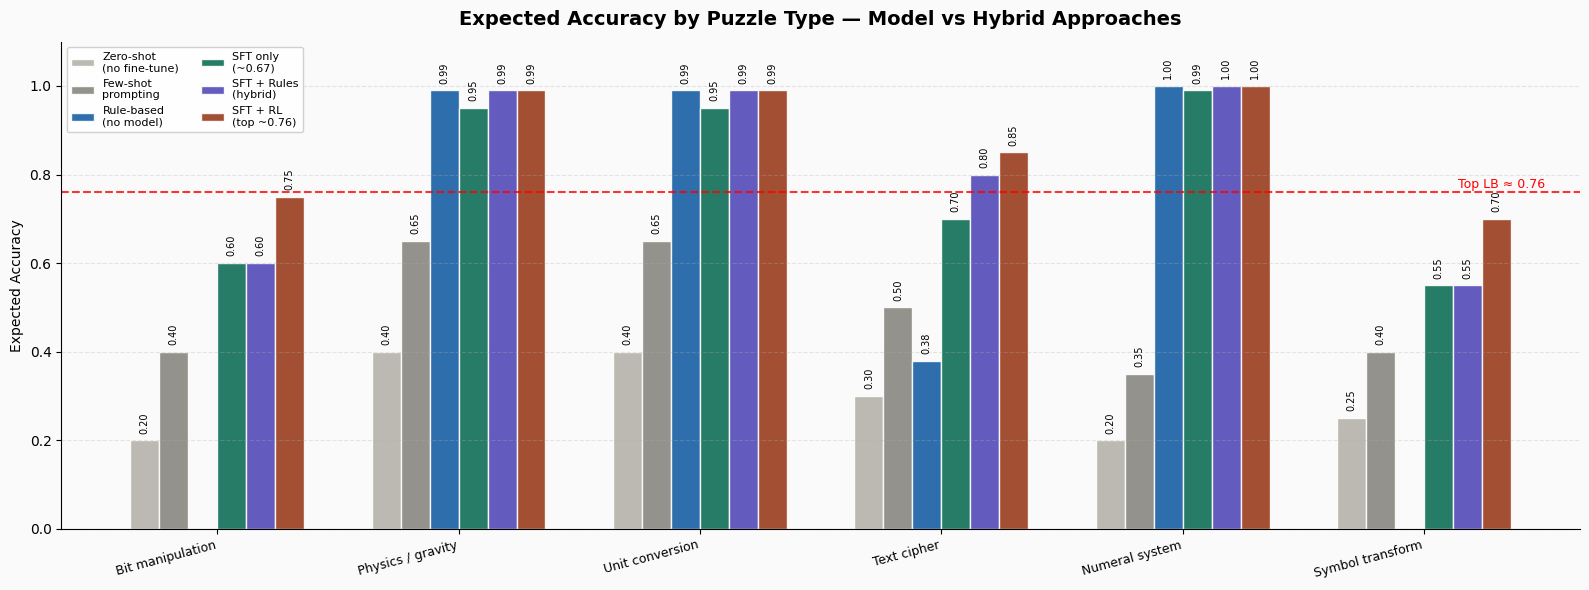

In [42]:
type_names = [LABELS[t] for t in types_ordered]

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#FAFAFA')

x = np.arange(len(type_names))
w = 0.12

ap_colors = ['#B4B2A9', '#888780', '#185FA5', '#0F6E56', '#534AB7', '#993C1D']

for i, (label, accs) in enumerate(approaches.items()):
    offset = (i - len(approaches)/2 + 0.5) * w
    
    bars = ax.bar(
        x + offset,
        accs,
        width=w,
        label=label,
        color=ap_colors[i],
        alpha=0.9,
        edgecolor='white'
    )
    
    # Add value labels (clean & small)
    for bar in bars:
        h = bar.get_height()
        if h > 0.05:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.015,
                f'{h:.2f}',
                ha='center',
                va='bottom',
                fontsize=7,
                rotation=90
            )

# -----------------------------
# Axes styling
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(type_names, fontsize=9, rotation=15, ha='right')

ax.set_ylabel('Expected Accuracy', fontsize=10)
ax.set_ylim(0, 1.1)

ax.set_title(
    'Expected Accuracy by Puzzle Type — Model vs Hybrid Approaches',
    fontsize=14,
    fontweight='bold',
    pad=12
)

# Grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# Leaderboard reference line
# -----------------------------
top_lb = 0.76
ax.axhline(top_lb, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

ax.text(
    len(type_names) - 0.5,
    top_lb + 0.01,
    'Top LB ≈ 0.76',
    color='red',
    fontsize=9,
    ha='right'
)

# -----------------------------
# Legend (clean)
# -----------------------------
ax.legend(
    loc='upper left',
    fontsize=8,
    ncol=2,
    frameon=True,
    framealpha=0.9
)

# Clean look
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#FAFAFA')

# -----------------------------
# Save & show
# -----------------------------
plt.tight_layout()
plt.savefig(
    'model_comparison.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#FAFAFA'
)

plt.show()

In [43]:
total_n = len(train)

type_weights = {
    t: len(train[train['type'] == t]) / total_n
    for t in types_ordered
    if len(train[train['type'] == t]) > 0
}

print('📊 Projected Overall Accuracy per Approach:')
print('-' * 60)

for name, accs in approaches.items():
    
    # Ensure alignment (very important)
    valid_pairs = [
        (acc, t) for acc, t in zip(accs, types_ordered)
        if t in type_weights
    ]
    
    if not valid_pairs:
        print(f"{name:<30} → 0.000")
        continue
    
    overall = sum(acc * type_weights[t] for acc, t in valid_pairs)
    
    print(f"{name.replace(chr(10), ' '):<30} → {overall:.3f}")

print('-' * 60)

📊 Projected Overall Accuracy per Approach:
------------------------------------------------------------
Zero-shot (no fine-tune)       → 0.221
Few-shot prompting             → 0.379
Rule-based (no model)          → 0.380
SFT only (~0.67)               → 0.627
SFT + Rules (hybrid)           → 0.648
SFT + RL (top ~0.76)           → 0.710
------------------------------------------------------------


##  Prompting Strategy Analysis

In [44]:
subset = train[train['type'] == 'bit_manipulation']

if subset.empty:
    raise ValueError("No bit_manipulation samples found!")

sample_row = subset.sample(1, random_state=42).iloc[0]
prompt_body = sample_row['prompt']

In [45]:
print('=' * 70)
print('FORMAT 1: Zero-shot (baseline ~0.20)')
print('=' * 70)

zeroshot = f"""{prompt_body}

Give only the final answer in \\boxed{{}}."""
print(zeroshot[:400])

FORMAT 1: Zero-shot (baseline ~0.20)
In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:
kgz tvrqlvs cvwwqk qtvrqazp -> the magical rabbit imagines
lvk zoisfczp wzmfay sqwcvcm -> cat explores beyond library
kzvlgzc pknyqzp azvc kfhzc -> teacher studies near tower
kncksz pknyqzp vwfuz qpsvay -> turtle studies above island
kncksz ycvhp yffc -> turtle draws door
Now, decrypt the following text: vsqlz


In [46]:
print('\n' + '=' * 70)
print('FORMAT 2: Chain-of-thought (SFT training)')
print('=' * 70)

cot = f"""{prompt_body}

Think step by step:

1. Identify this as a bit manipulation puzzle (8-bit binary).
2. Compare each input-output pair carefully.
3. Determine the transformation rule:
   - bit flip?
   - shift?
   - XOR / AND / OR?
   - position-based mapping?
4. Validate the rule across ALL examples.
5. Apply it to the final query input.

Return only the final answer in \\boxed{{}}."""
print(cot[:500])



FORMAT 2: Chain-of-thought (SFT training)
In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:
kgz tvrqlvs cvwwqk qtvrqazp -> the magical rabbit imagines
lvk zoisfczp wzmfay sqwcvcm -> cat explores beyond library
kzvlgzc pknyqzp azvc kfhzc -> teacher studies near tower
kncksz pknyqzp vwfuz qpsvay -> turtle studies above island
kncksz ycvhp yffc -> turtle draws door
Now, decrypt the following text: vsqlz lczvkzp kgz yvcx pzlczk

Think step by step:

1. Identify this as a bit manipulation puzzle (8-bit 


In [47]:
print('\n' + '=' * 70)
print('FORMAT 3: Type-aware system prompt (best for SFT)')
print('=' * 70)

system_aware = """You are an expert in solving Alice's Wonderland puzzles.

TASK TYPE: Bit Manipulation (8-bit binary)

Strict reasoning process:
1. Parse all input → output examples.
2. Identify the exact bitwise transformation rule.
3. Ensure the rule works for every example (no exceptions).
4. Apply the SAME rule to the query input.

Important constraints:
- Output must be exactly 8 binary digits (0/1).
- No explanations in final answer.
- Do not guess — verify pattern first.

Final format:
\\boxed{xxxxxxxx}  (8-bit binary only)
"""

print(system_aware)


FORMAT 3: Type-aware system prompt (best for SFT)
You are an expert in solving Alice's Wonderland puzzles.

TASK TYPE: Bit Manipulation (8-bit binary)

Strict reasoning process:
1. Parse all input → output examples.
2. Identify the exact bitwise transformation rule.
3. Ensure the rule works for every example (no exceptions).
4. Apply the SAME rule to the query input.

Important constraints:
- Output must be exactly 8 binary digits (0/1).
- No explanations in final answer.
- Do not guess — verify pattern first.

Final format:
\boxed{xxxxxxxx}  (8-bit binary only)



## Local Evaluation Framework

In [48]:
def extract_answer(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    
    # Priority 1: boxed
    m = re.search(r'\\boxed\{([^}]*)\}', text)
    if m:
        return m.group(1).strip()
    
    # Priority 2: binary (8-bit)
    m = re.search(r'\b[01]{8}\b', text)
    if m:
        return m.group(0)
    
    # Priority 3: number (last)
    nums = re.findall(r'-?\d+\.?\d*', text)
    if nums:
        return nums[-1]
    
    # Priority 4: last word
    return text.strip().split()[-1]

In [49]:
def is_correct(pred, truth, rel_tol=1e-4):
    if pred == '' or pred is None:
        return False
    
    try:
        p = float(pred)
        t = float(truth)
        return abs(p - t) / max(abs(t), 1e-9) < rel_tol
    except:
        return str(pred).strip().upper() == str(truth).strip().upper()

In [50]:
def evaluate_local(model_outputs: dict, ground_truth: pd.DataFrame):
    
    df = ground_truth.copy()
    
    # Map predictions
    df['raw_output'] = df['id'].map(model_outputs).fillna('')
    df['pred'] = df['raw_output'].apply(extract_answer)
    
    # Vectorized correctness
    df['correct'] = [
        is_correct(p, t) for p, t in zip(df['pred'], df['answer'])
    ]
    
    overall = df['correct'].mean()
    per_type = df.groupby('type')['correct'].mean().sort_values(ascending=False)
    
    # -----------------------------
    # Print results
    # -----------------------------
    print(f'🎯 Overall accuracy: {overall:.4f}\n')
    print('📊 Per-type accuracy:')
    
    for t, acc in per_type.items():
        print(f'  {LABELS.get(t, t):<22} {acc:.4f}')
    
    # -----------------------------
    # Debug: show wrong predictions 🔥
    # -----------------------------
    wrong = df[~df['correct']]
    
    print(f'\n❌ गलत predictions: {len(wrong)}')
    
    if len(wrong) > 0:
        print('\nSample errors:')
        display(wrong[['type','pred','answer']].head(5))
    
    return {
        'overall': overall,
        'per_type': per_type.to_dict(),
        'details': df
    }


In [51]:
solver_map = {
    'numeral_system':  solve_roman,
    'physics_gravity': solve_physics,
    'unit_conversion': solve_unit,
    'text_cipher':     solve_cipher,
}

val = train.sample(frac=0.2, random_state=42).copy()

mock_outputs = {}

for _, row in val.iterrows():
    fn = solver_map.get(row['type'])
    
    if fn:
        pred = fn(row['prompt'])
        mock_outputs[row['id']] = f'\\boxed{{{pred}}}' if pred else ''
    else:
        mock_outputs[row['id']] = ''


print('🧪 Rule-based solver evaluation (20% split)')
print('=' * 60)

results = evaluate_local(mock_outputs, val[['id','answer','type']])

🧪 Rule-based solver evaluation (20% split)
🎯 Overall accuracy: 0.2221

📊 Per-type accuracy:
  Numeral system         1.0000
  Text cipher            0.4034
  Bit manipulation       0.0000
  other                  0.0000
  Symbol transform       0.0000
  Unit conversion        0.0000

❌ गलत predictions: 1478

Sample errors:


,type,pred,answer
952,bit_manipulation,,11100111
6599,symbol_transform,,\&[[
2554,unit_conversion,37.82,20.72
4519,bit_manipulation,,10010110
1557,bit_manipulation,,00000111


## Thank you...pls upvote!!!!!!!!!!!